# Fed, Pieniądz i Rynki - Pobieranie Danych

**Źródło:** FRED API (Federal Reserve Economic Data)  
**Zakres:** 1990-01-01 do dziś  

| Seria | Opis | Częstotliwość |
|-------|------|---------------|
| FEDFUNDS | Stopa procentowa Fed | Monthly |
| M2SL | Podaż pieniądza M2 | Monthly |
| SP500 | Indeks S&P500 | Monthly |
| T10Y2Y | Spread 10Y-2Y (yield curve) | Daily |
| USREC | Okresy recesji NBER (0/1) | Monthly |
| UNRATE | Bezrobocie | Monthly |
| GDPC1 | PKB realne USA | Quarterly |
| CPIAUCSL | Inflacja CPI | Monthly |

In [1]:
import requests
import pandas as pd
import os
from pathlib import Path
import time

# Ścieżki
RAW_DIR = Path('../data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)

print('Katalog danych:', RAW_DIR)

Katalog danych: ../data/raw


## 1. Konfiguracja serii FRED

FRED API nie wymaga klucza dla podstawowych zapytań - używamy publicznego endpointu.

In [2]:
# Serie do pobrania
SERIES = {
    'FEDFUNDS': 'Stopa procentowa Fed (%)',
    'M2SL':     'Podaż pieniądza M2 (mld USD)',
    'T10Y2Y':   'Spread 10Y-2Y - yield curve (pp)',
    'USREC':    'Recesja NBER (1=recesja, 0=brak)',
    'UNRATE':   'Stopa bezrobocia (%)',
    'GDPC1':    'PKB realne USA (mld USD, kwartalnie)',
    'CPIAUCSL': 'Inflacja CPI (indeks)',
    # Seria dodane w Dniu 5 - wczesniej pobierane poza notebookiem, przez co
    # projekt nie odtwarzal sie od zera: v_master deklarowal te kolumny, a zadna
    # komorka ich nie ladowala.
    'ICSA':         'Wnioski o zasilek dla bezrobotnych (tyg.)',
    'PAYEMS':       'Zatrudnienie poza rolnictwem (tys. osob)',
    'INDPRO':       'Produkcja przemyslowa (indeks)',
    'RSXFS':        'Sprzedaz detaliczna (mln USD)',
    'PERMIT':       'Pozwolenia budowlane (tys.)',
    'BAMLH0A0HYM2': 'Spread obligacji High Yield (pp)',
    'DRTSCILM':     'Zaostrzenie warunkow kredytowych (%, kwartalnie)',
    'USSLIND':      'Wskaznik wyprzedzajacy LEI (wycofany przez FRED w 2020)',
}

START_DATE = '1990-01-01'
BASE_URL = 'https://fred.stlouisfed.org/graph/fredgraph.csv'

print(f'Liczba serii do pobrania: {len(SERIES)}')
print(f'Zakres dat: {START_DATE} → dziś')

Liczba serii do pobrania: 15
Zakres dat: 1990-01-01 → dziś


## 2. Pobieranie danych z FRED

In [6]:
def pobierz_serie(series_id, start_date=START_DATE):
    """
    Pobiera serię z FRED i zwraca DataFrame z kolumnami: date, value.
    Używa publicznego CSV endpointu - bez klucza API.
    """
    url = f'{BASE_URL}?id={series_id}&vintage_date=&realtime_start=&realtime_end='
    params = {'id': series_id}
    
    try:
        response = requests.get(BASE_URL, params=params, timeout=15)
        response.raise_for_status()
        
        from io import StringIO
        df = pd.read_csv(StringIO(response.text))
        df.columns = ['date', 'value']
        df['date'] = pd.to_datetime(df['date'])
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df = df[df['date'] >= start_date].reset_index(drop=True)
        df['series_id'] = series_id
        
        return df
    except Exception as e:
        print(f'  BŁĄD dla {series_id}: {e}')
        return None


# Pobierz wszystkie serie
dane = {}

for series_id, opis in SERIES.items():
    print(f'Pobieranie: {series_id} - {opis}...', end=' ')
    df = pobierz_serie(series_id)
    
    if df is not None:
        dane[series_id] = df
        print(f'OK ({len(df)} wierszy, {df["date"].min().date()} → {df["date"].max().date()})')
    
    time.sleep(0.5)  # grzeczność wobec serwera FRED

print(f'\nPobrano {len(dane)}/{len(SERIES)} serii.')

Pobieranie: FEDFUNDS — Stopa procentowa Fed (%)...   BŁĄD dla FEDFUNDS: name 'requests' is not defined


NameError: name 'time' is not defined

## 3. Zapis do CSV

In [3]:
# S&P500 i VIX z Yahoo Finance - pelna historia od 1990.
# FRED bez klucza oddaje SP500 tylko 10 lat, a VIX-a nie ma w ogole.
# Nadpisujemy, nie scalamy: yfinance zwraca cala historie przy kazdym pobraniu.
import yfinance as yf

YAHOO = {'^GSPC': 'SP500', '^VIX': 'VIX'}

for ticker, series_id in YAHOO.items():
    raw = yf.download(ticker, start=START_DATE, progress=False)
    miesieczne = (
        raw['Close']
        .resample('MS').mean()          # srednia miesieczna, tak jak v_master usrednia serie dzienne
        .reset_index()
    )
    miesieczne.columns = ['date', 'value']
    miesieczne['date'] = miesieczne['date'].dt.strftime('%Y-%m-%d')
    miesieczne['series_id'] = series_id
    miesieczne = miesieczne.dropna()
    miesieczne.to_csv(RAW_DIR / f'{series_id}.csv', index=False)
    print(f'{series_id:<6} {len(miesieczne):>4} miesiecy '
          f'({miesieczne["date"].iloc[0]} -> {miesieczne["date"].iloc[-1]})')

SP500   441 miesiecy (1990-01-01 -> 2026-09-01)


VIX     441 miesiecy (1990-01-01 -> 2026-09-01)


In [7]:
for series_id, df in dane.items():
    sciezka = RAW_DIR / f'{series_id}.csv'

    # Scalanie zamiast nadpisania. FRED ogranicza historie serii licencjonowanych:
    # BAMLH0A0HYM2 oddaje dzis tylko 3 ostatnie lata, SP500 dziesiec. Nadpisanie
    # kasowaloby historie pobrana wczesniej, wiec plik narasta, a swieze wartosci
    # maja pierwszenstwo przy powtorzonej dacie (FRED rewiduje odczyty wstecz).
    if sciezka.exists():
        historia = pd.read_csv(sciezka, parse_dates=['date'])
        df = pd.concat([historia, df], ignore_index=True)

    df = (df.sort_values('date')
            .drop_duplicates(subset='date', keep='last')
            .reset_index(drop=True))
    df['series_id'] = series_id
    df.to_csv(sciezka, index=False)
    print(f'Zapisano: {sciezka.name} ({len(df)} wierszy)')

## 4. Przegląd pobranych danych

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Podsumowanie: zakres dat, brakujące wartości, statystyki
print('=' * 70)
print(f'{"Seria":<12} {"Wiersze":>8} {"Od":>12} {"Do":>12} {"Brak":>6} {"Min":>10} {"Max":>10}')
print('=' * 70)

for series_id, df in dane.items():
    braki = df['value'].isna().sum()
    print(
        f'{series_id:<12}'
        f'{len(df):>8}'
        f'{str(df["date"].min().date()):>12}'
        f'{str(df["date"].max().date()):>12}'
        f'{braki:>6}'
        f'{df["value"].min():>10.2f}'
        f'{df["value"].max():>10.2f}'
    )

print('=' * 70)

Seria         Wiersze           Od           Do   Brak        Min        Max
FEDFUNDS         440  1990-01-01  2026-08-01     0      0.05      8.29
M2SL             439  1990-01-01  2026-07-01     0   3166.30  23218.00
SP500           2610  2016-09-12  2026-09-11    96   2085.18   7798.99
T10Y2Y          9575  1990-01-01  2026-09-11   395     -1.08      2.91
USREC            440  1990-01-01  2026-08-01     0      0.00      1.00
UNRATE           440  1990-01-01  2026-08-01     1      3.40     14.80
GDPC1            146  1990-01-01  2026-04-01     0   9951.92  24269.61
CPIAUCSL         440  1990-01-01  2026-08-01     1    127.50    334.13
ICSA            1914  1990-01-06  2026-09-05     0 189000.006137000.00
PAYEMS           440  1990-01-01  2026-08-01     0 108253.00 159075.00
INDPRO           439  1990-01-01  2026-07-01     0     60.33    104.10
RSXFS            415  1992-01-01  2026-07-01     0 142120.00 665054.00
PERMIT           439  1990-01-01  2026-07-01     0    513.00   2263.00


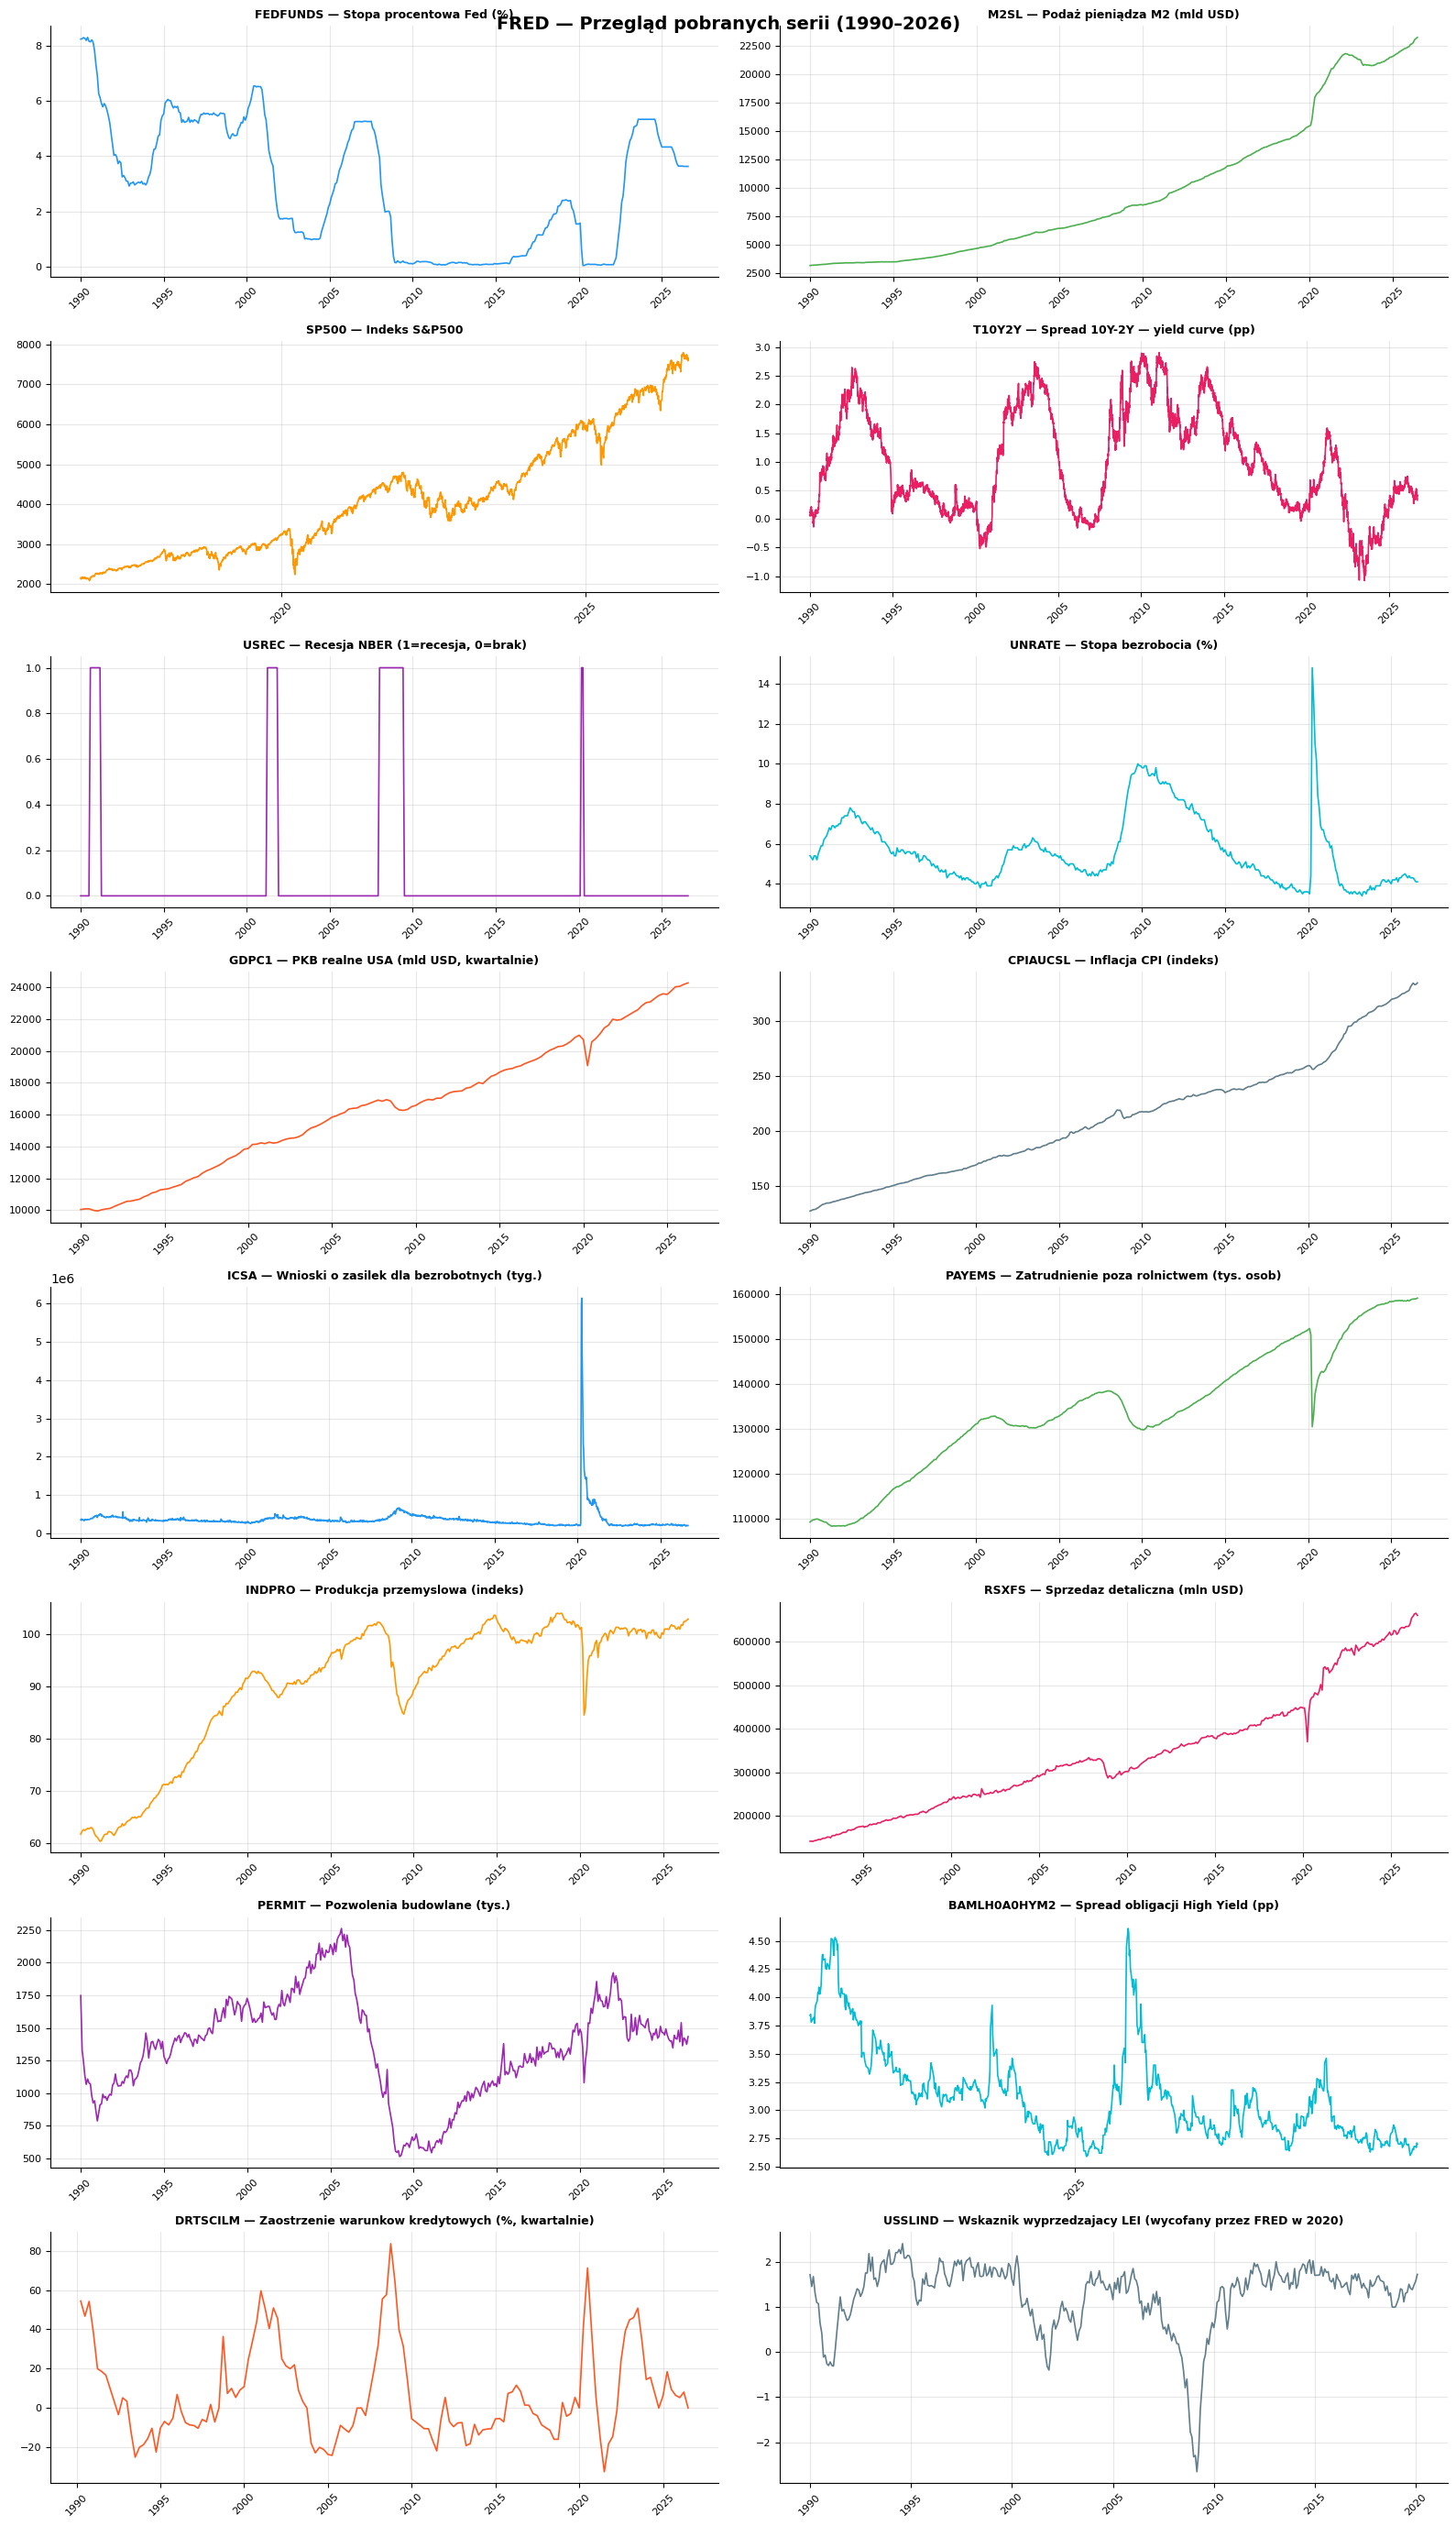

Wykres zapisany: reports/00_przeglad_serii.png


In [6]:
# Szybki podgląd wszystkich serii na jednym wykresie
# siatka dopasowuje sie do liczby serii - przy sztywnym 4x2 dolozenie
# kolejnej serii konczylo sie IndexError
n_wierszy = -(-len(dane) // 2)
fig, axes = plt.subplots(n_wierszy, 2, figsize=(16, 3.5 * n_wierszy))
fig.suptitle('FRED - Przegląd pobranych serii (1990-2026)', fontsize=14, fontweight='bold')
axes = axes.flatten()

kolory = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4', '#FF5722', '#607D8B']
kolory = [kolory[i % len(kolory)] for i in range(len(dane))]

for i, (series_id, df) in enumerate(dane.items()):
    ax = axes[i]
    df_clean = df.dropna(subset=['value'])
    ax.plot(df_clean['date'], df_clean['value'], color=kolory[i], linewidth=1.2)
    ax.set_title(f'{series_id} - {SERIES[series_id]}', fontsize=9, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[len(dane):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('../reports/00_przeglad_serii.png', dpi=150, bbox_inches='tight')
plt.show()
print('Wykres zapisany: reports/00_przeglad_serii.png')

## 5. Kontrola jakości danych

Sprawdź:
- Czy SP500 ma luki (seria dzienna vs miesięczna)?
- Czy GDPC1 ma kwartalną częstotliwość (mniej obserwacji)?
- Czy USREC zawiera tylko 0 i 1?

In [7]:
# SP500 - sprawdź luki
if 'SP500' in dane:
    sp = dane['SP500'].dropna()
    print(f'SP500: {len(sp)} obserwacji, częstotliwość: {sp["date"].diff().median().days} dni między obserwacjami')

# GDPC1 - PKB kwartalnie
if 'GDPC1' in dane:
    gdp = dane['GDPC1'].dropna()
    print(f'GDPC1: {len(gdp)} obserwacji (oczekiwane ~{(2026-1990)*4} kwartałów)')

# USREC - tylko 0 i 1
if 'USREC' in dane:
    unikalne = dane['USREC']['value'].dropna().unique()
    miesiace_recesji = int(dane['USREC']['value'].sum())
    print(f'USREC: unikalne wartości = {sorted(unikalne)}, miesięcy recesji = {miesiace_recesji}')

SP500: 2514 obserwacji, częstotliwość: 1 dni między obserwacjami
GDPC1: 146 obserwacji (oczekiwane ~144 kwartałów)
USREC: unikalne wartości = [np.int64(0), np.int64(1)], miesięcy recesji = 36


In [8]:
# Podsumowanie - gotowe do następnego kroku
print('DANE GOTOWE DO KROKU 2 (SQLite)')
print()
pliki = list(RAW_DIR.glob('*.csv'))
print(f'Zapisanych plików CSV: {len(pliki)}')
for p in sorted(pliki):
    rozmiar = p.stat().st_size / 1024
    print(f'  {p.name:<20} {rozmiar:.1f} KB')

DANE GOTOWE DO KROKU 2 (SQLite)

Zapisanych plików CSV: 18
  BAMLH0A0HYM2.csv     221.5 KB
  CPIAUCSL.csv         11.6 KB
  DRTSCILM.csv         3.6 KB
  FEDFUNDS.csv         10.7 KB
  GDPC1.csv            3.8 KB
  ICSA.csv             43.0 KB
  INDPRO.csv           11.2 KB
  M2SL.csv             10.0 KB
  PAYEMS.csv           10.8 KB
  PERMIT.csv           9.8 KB
  RSXFS.csv            9.7 KB
  SP500.csv            65.4 KB
  SP500_full.csv       15.3 KB
  T10Y2Y.csv           213.7 KB
  UNRATE.csv           9.5 KB
  USREC.csv            8.2 KB
  USSLIND.csv          8.5 KB
  VIX.csv              14.5 KB
